In [123]:
import astropy

In [124]:
from astropy import units as u
from astropy import time

import numpy as np

from poliastro import iod
from poliastro.bodies import Body,Mars, Earth, Venus, Jupiter, Saturn, Uranus, Neptune, Sun, Europa, Ganymede, Callisto, Io, Titan
from poliastro.ephem import Ephem
from poliastro.maneuver import Maneuver
from poliastro.twobody import Orbit
from poliastro.util import time_range
from poliastro.plotting import OrbitPlotter3D, StaticOrbitPlotter
import math
import matplotlib.pyplot as plt
# More info: https://plotly.com/python/renderers/
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

from astropy.coordinates import solar_system_ephemeris


solar_system_ephemeris.set("jpl")

<ScienceState solar_system_ephemeris: 'jpl'>

In [125]:
#starship specs
isp = 380
dry_mass = 150
prop_mass = 1600 #tons
lmo_fuel = 250


landing_reserve = 0

starship_dv = isp*9.81*math.log((dry_mass+prop_mass)/dry_mass)
# boiloff = 0#0 
print(starship_dv)

# #for a skimpy 100t starship, only need 20 tons of landing fuel
# print(isp*9.81*math.log((120)/(100)))



9158.219613923256


In [126]:

#launch from body_1 to body_2
body_1 = Earth
body_2 = Jupiter
# print(body_1.escape_velocity())

#solve for a minimum ejection DV given a time period
transitTime = 750*u.day
resolution = 1*u.day
start_date = time.Time("2035-01-01 00:01", scale="utc").tdb
end_date = time.Time("2035-12-31 00:01", scale="utc").tdb
print(type(time_range(start_date, end=end_date+transitTime)))

<class 'astropy.time.core.Time'>


/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"



In [127]:
print(end_date - start_date)

363.99999999970674


In [128]:


ephem_1 = Ephem.from_body(body_1, time_range(start_date, end=end_date+transitTime))
ephem_2 = Ephem.from_body(body_2, time_range(start_date, end=end_date+transitTime))




delta_time = end_date-start_date
lowest_dv = 100000
lowest_date = 0
lowest_orb = 0
for i in range(int(delta_time/resolution)):
    date_launch = start_date+i*resolution
    date_arrival = start_date+transitTime+i*resolution
    # Solve for departure and target orbits
    ss_planet_1 = Orbit.from_ephem(Sun, ephem_1, date_launch)
    ss_planet_2 = Orbit.from_ephem(Sun, ephem_2, date_arrival)

    # Solve for the transfer maneuver
    man_lambert = Maneuver.lambert(ss_planet_1, ss_planet_2,M=0)
    ejection = man_lambert[0]
    dv = np.linalg.norm(ejection[1].value)
    if(dv<lowest_dv):
        lowest_dv=dv
        lowest_date = date_launch
        lowest_orb,final = ss_planet_1.apply_maneuver(man_lambert, intermediate=True)



reserve_dv = starship_dv-int(lowest_dv)-landing_reserve
#print(f"Starship DV is {starship_dv}m/s")   
print(f"Ejection is with {int((1)*lowest_dv)}m/s of DV (in sun reference frame")
print(f"departure from {body_1} on {lowest_date}")
print(f"arrival at {body_2} on {lowest_date+transitTime}")
      
dM = 0*u.day

# fig, ax = plt.subplots()

# ax.grid(True)
ss_leave_1 = Orbit.from_ephem(Sun, ephem_1, lowest_date)
ss_arrival_2 = Orbit.from_ephem(Sun, ephem_2, lowest_date+transitTime)

#ax.set_title("2033 90 day trajectory")
dep_v_inf=lowest_orb.v-ss_leave_1.v
est_c3=np.dot(dep_v_inf,dep_v_inf).to((u.km*u.km)/(u.s*u.s))
print(f"Estimated C3 is {est_c3:.1f}")


Ejection is with 9025m/s of DV (in sun reference frame
departure from Earth (♁) on 2035-07-18 00:02:09.184
arrival at Jupiter (♃) on 2037-08-06 00:02:09.184
Estimated C3 is 81.5 km2 / s2


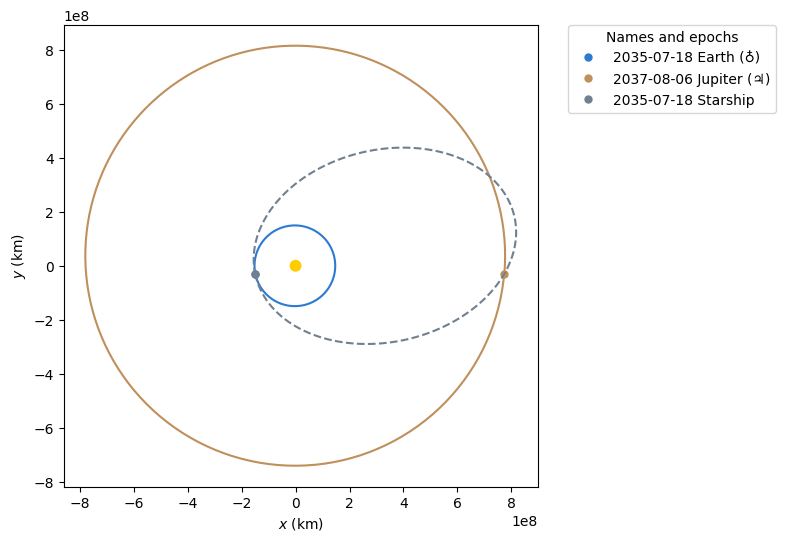

In [129]:
# We can check new bodies positions
plotter = StaticOrbitPlotter()


plotter.plot_body_orbit(body_1,  lowest_date+dM, label=body_1)

plotter.plot_body_orbit(body_2,  lowest_date+dM+transitTime, label=body_2)
label_str = lowest_date.datetime.strftime("%Y-%m-%d")


#plotter.plot(ss_leave_1, label=label_str)

plotter.plot(lowest_orb, color="slategrey", label="Starship")

In [130]:
#Find SOI change on departure
#for the optimized trajectory, re get the epherimis
date_launch = lowest_date
date_arrival = lowest_date+transitTime
#ss_earth = Orbit.from_ephem(Sun, earth, date_launch)

#arrival body is body 2
ss_body_1 = Orbit.from_ephem(Sun, ephem_1, date_launch)


#calculate SOI crossing point
ss_transfer = lowest_orb
ss_final = lowest_orb
time_sliver = 0.01*u.day
steps = int(((transitTime+3*u.day)/time_sliver).value)
print(f"{steps} steps")
soi_change_point = lowest_date+transitTime
for i in range(steps):
    ss_final = ss_transfer.propagate(i*time_sliver)
    arrival_distance = np.linalg.norm(ss_final.r-ss_body_1.r)
    #print(earth_distance)
    grav_difference = Sun.mass/(np.linalg.norm(ss_final.r)**2)-body_1.mass/((arrival_distance)**2)
    #print(grav_difference)
    if(grav_difference>0):
        print(f"Departure at step{i}")
        soi_change_point = date_launch+i*time_sliver
        break


print(f"Departed SOI on {soi_change_point}")



75300 steps
Departure at step8
Departed SOI on 2035-07-18 01:57:21.184


In [131]:
ss_final = lowest_orb.propagate(soi_change_point-date_launch) 


r_body_1, v_body_1 = ss_body_1.r,ss_body_1.v
r_sc_arriv = ss_final.r-r_body_1
v_sc_arriv = ss_final.v-v_body_1
# c3_a = np.linalg.norm(v_sc_arriv)**2
c3_a=est_c3
print(f"Soi change at {np.linalg.norm(r_sc_arriv)} (potentially seems low tbf)")
print(f"C3 is {c3_a}")



Soi change at 264919.04122708587 km (potentially seems low tbf)
C3 is 81.45939156838809 km2 / s2


6678 x 67978 km x 0.0 deg (GCRS) orbit around Earth (♁) at epoch 2035-07-18 00:02:09.184 (TDB)


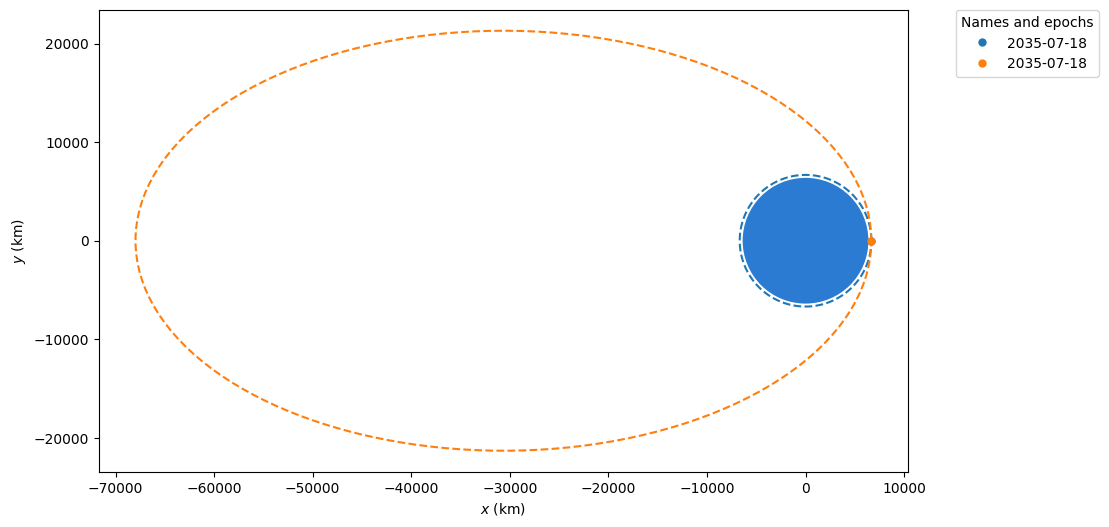

In [132]:
#If the parking orbit is to be elliptical, calculate 

#circular initial
r_p = 300*u.km#parking orbit
circular_orbit = Orbit.circular(body_1,alt = r_p,epoch = date_launch)
boost=2.7*u.km/u.s
prograde_vector=(circular_orbit.v/(np.linalg.norm(circular_orbit.v))).value
boost_effective_man=Maneuver((0*u.s,boost*prograde_vector))
parking_orbit=circular_orbit.apply_maneuver(boost_effective_man)
plotter=StaticOrbitPlotter()
plotter.plot(circular_orbit)
plotter.plot(parking_orbit)
print(parking_orbit)



Start in 6678 x 67978 km x 0.0 deg (GCRS) orbit around Earth (♁) at epoch 2035-07-18 00:02:09.184 (TDB)
Ejection towards Jupiter (♃) from Earth (♁)
Starship DV is 9158.219613923256m/s
Ejection velocity is 14.171596277260369 km / s
Ejection DV is 3.7458358138085064 km / s
Ejection C3 is 81.45939156838811
Starship has 5412.383800114751 m / s of DV after the burn excluding landing reserve (0 m/s)


/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "utctai" yielded 1 of "dubious year (Note 3)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "taiutc" yielded 150 of "dubious year (Note 4)"



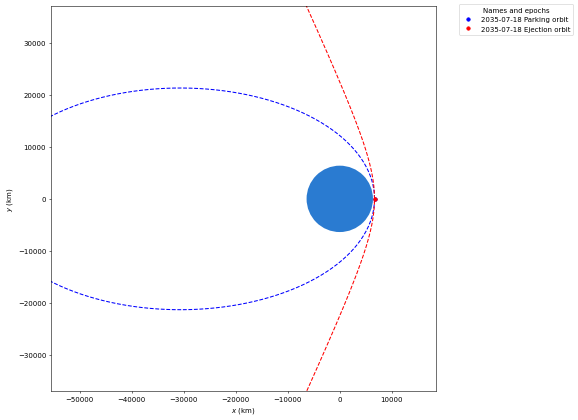

In [133]:


a_exit = -(body_1.k / c3_a).to(u.km)
ecc_exit = 1 - (r_p+body_1.R) / a_exit

departure_orbit = Orbit.from_classical(
    body_1,
    a_exit,
    ecc_exit,
    0 * u.deg,
    0 * u.deg,
    0 * u.deg,
    0 * u.deg,  # We don't mind
    time.Time(date_launch, scale="utc"),
)
print(f"Start in {parking_orbit}")
print(f"Ejection towards {body_2} from {body_1}")
print(f"Starship DV is {starship_dv}m/s")   
print(f"Ejection velocity is {np.linalg.norm(departure_orbit.v)}")
print(f"Ejection DV is {np.linalg.norm(departure_orbit.v)-np.linalg.norm(parking_orbit.v)}")
ejection_c3 = -(body_1.k/(departure_orbit.a.to(u.m))).value/1000000
print(f"Ejection C3 is {ejection_c3}")



ejection_dv = (np.linalg.norm(departure_orbit.v)-np.linalg.norm(parking_orbit.v)).value
reserve_dv = starship_dv-(ejection_dv*1000)-landing_reserve
print(f"Starship has {reserve_dv} m / s of DV after the burn excluding landing reserve ({landing_reserve} m/s)")


fig, ax = plt.subplots(
    figsize=(10, 10),  # inches
    dpi=50            # resolution
)

earth_plotter = StaticOrbitPlotter(ax)
earth_plotter.plot(parking_orbit, label="Parking orbit", color="b")
earth_plotter.plot(departure_orbit, label="Ejection orbit", color="r")

# Get the matplotlib Axes (poliastro versions differ: ax vs _ax)
ax = getattr(earth_plotter, "ax", None) or earth_plotter._ax

# Example: zoom to a +/- 5e8 km box around (0,0)
plot_range=3.7e4
ax.set_xlim(-1.5*plot_range, 0.5*plot_range)
ax.set_ylim(-plot_range, plot_range)
ax.set_aspect("equal", adjustable="box")

plt.show()




Soi of Jupiter (♃) is approximately 52.9 million km
Entered SOI at 2037-05-03 21:38:09.184
Arrival V-infinity is 6.51 km / s


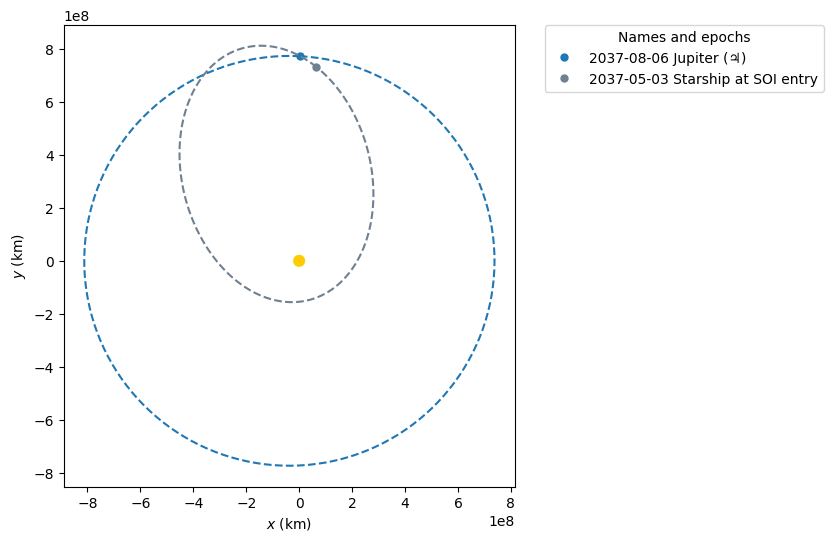

In [134]:
date_launch = lowest_date
date_arrival = lowest_date+transitTime


#propagate starship orbit in sun frame to arrival
ss_body_2 = Orbit.from_ephem(Sun, ephem_2, date_arrival)
ss_arrival=lowest_orb.propagate(date_arrival)
plotter=StaticOrbitPlotter()
plotter.plot(ss_body_2, label=body_2)
#propagate orbit back until at edge of SOI
step=0.1*u.day
body_2_soi=body_2.hill_radius(ss_body_2.a,Sun)
print(f"Soi of {body_2} is approximately {body_2_soi.to(u.km).value/1e6:.1f} million km")
ss_body_2_reverse=ss_body_2.propagate(0*u.s)
while np.linalg.norm(ss_arrival.r-ss_body_2_reverse.r)<body_2_soi:
    ss_arrival=ss_arrival.propagate(-step)
    ss_body_2_reverse=ss_body_2_reverse.propagate(-step)
print("Entered SOI at",ss_arrival.epoch)
plotter.plot(ss_arrival, color="slategrey", label="Starship at SOI entry")

r_infty=ss_arrival.r - ss_body_2_reverse.r
v_infty=ss_arrival.v - ss_body_2_reverse.v
v_infty_mag=np.linalg.norm(v_infty)
print(f"Arrival V-infinity is {v_infty_mag:.2f}")


<bound method Orbit.classical of 43411 x -6782204 km x 156.7 deg (JupiterICRS) orbit around Jupiter (♃) at epoch 2037-05-03 21:38:09.184 (TDB)>
6.511264360140582 km / s


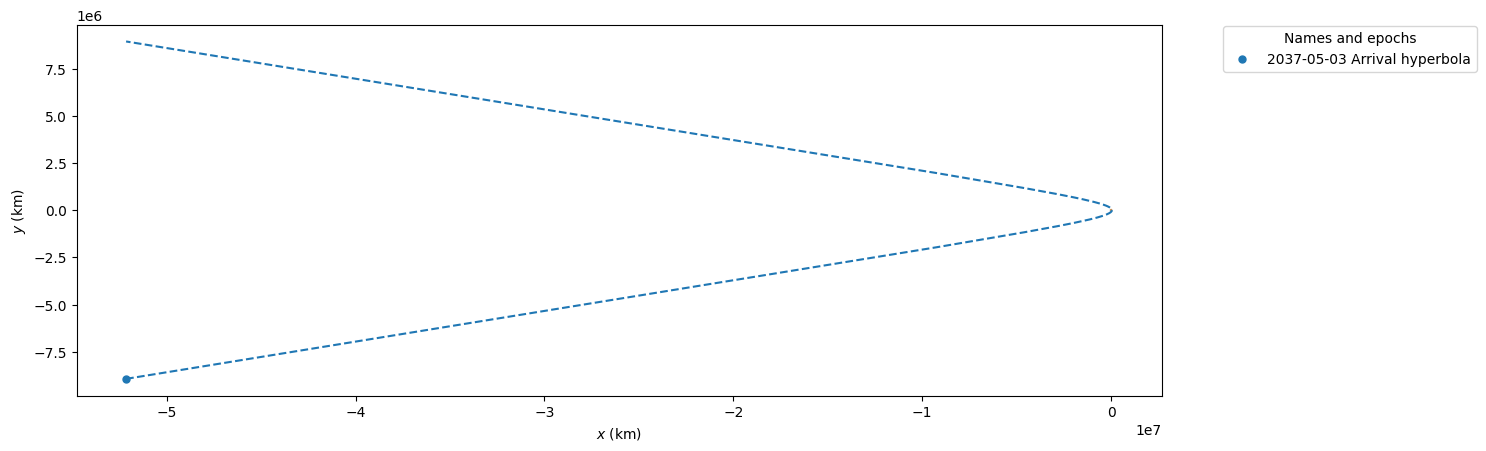

In [135]:
#Now generate orbit that flies past body 2
target_r_p=body_2.R*1.5 #periapsis here is from center of body 2

body_2_arrival_orb=Orbit.from_vectors(
    body_2,r_infty,v_infty,epoch=ss_arrival.epoch)
print(body_2_arrival_orb.classical)
plotter=StaticOrbitPlotter()
plotter.plot(body_2_arrival_orb, label="Arrival hyperbola")
print(np.linalg.norm(body_2_arrival_orb.v))

Arrival speed (at periapsis) would be 58.467133231266274 km / s
Burn is 5412.383800114751 m/s
After deacceleration burn it is 7.793584524795691 km / s
Pre Entry orbit characteristics are periapsis 3574.6000000002823 km and apoapsis -6124060.164618457 km
Entry C3 is 42.39656356763766 km^2/s^2
Sus C3 is -126.40389166812247 km2 / s2
Need to lose -50.3098500097911 km / s in initial aerocapture pass assuming very low perijove


/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "utctai" yielded 1 of "dubious year (Note 3)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "utctai" yielded 1 of "dubious year (Note 3)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA function "taiutc" yielded 150 of "dubious year (Note 4)"

/home/jack/Documents/miniforge3-n/envs/cleanastronomy/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning:

ERFA

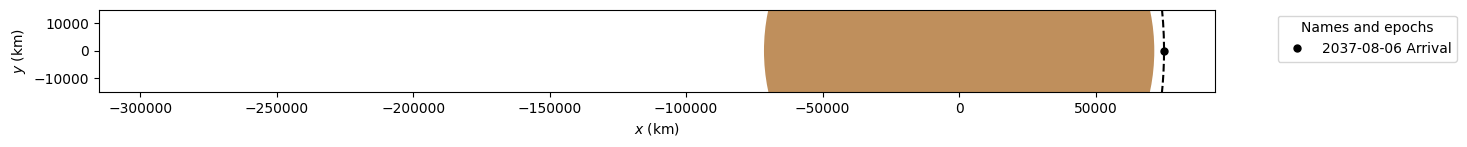

In [136]:

c3_a = np.linalg.norm(v_infty_mag)**2


#C3 only orbit calc
r_p = Jupiter.R*0.05#arrival periapsis
a_exit = -(body_2.k / c3_a).to(u.km)
ecc_exit = 1 - (r_p+body_2.R) / a_exit

arrival_orbit = Orbit.from_classical(
    body_2,
    a_exit,
    ecc_exit,
    0 * u.deg,
    0 * u.deg,
    0 * u.deg,
    0 * u.deg,  
    time.Time(date_arrival, scale="utc"),
)

retro_time=0*u.s

pre_burn_orbit = arrival_orbit.propagate(-retro_time)
#perform the retro burn
prograde_vector = (pre_burn_orbit.v/(np.linalg.norm(pre_burn_orbit.v))).value
#offset by a little as we dont want periapsis going into the atmosphere
rad_vector = (pre_burn_orbit.r/(np.linalg.norm(pre_burn_orbit.r))).value
rad_offset_weight = 0.1
retro_vector = -(prograde_vector-rad_offset_weight*rad_vector)
retro_vector = retro_vector/np.linalg.norm(retro_vector)

# print(prograde_vector)


##no deaccleration burn for arriving at Earth for now


burn_dv = 0*0.001*reserve_dv*(retro_vector)
#print(burn_dv)
# else:
#     burn_dv = 0*prograde_vector

retro_burn = Maneuver((0*u.s,burn_dv*u.km/u.s))
#retro_burn = Maneuver((0*u.s,[0,1,0]*u.km/u.s))
post_burn_orbit = pre_burn_orbit.apply_maneuver(retro_burn)

#print(f"New periapsis is {post_burn_orbit.r_p-body_2.R}km")

ax = plt.gca()       # or plotter.ax if you stored it directly
ax.set_ylim([-1.5e4, 1.5e4]) 

earth_plotter = StaticOrbitPlotter(ax)

#print(f"State vectors post burn are {post_burn_orbit.r} and {post_burn_orbit.v}.")



earth_plotter.plot(arrival_orbit, label="Arrival", color="k")
#earth_plotter.

# print(post_burn_orbit.v)
# print(post_burn_orbit.r)

post_burn_orbit_periapsis = post_burn_orbit.propagate(-post_burn_orbit.t_p)
# earth_plotter.plot(post_burn_orbit, label="Arrival", color="b")

arrival_circular_orbit = Orbit.circular(body_2,alt = 200*u.km)


print(f"Arrival speed (at periapsis) would be {np.linalg.norm(arrival_orbit.v)}")
print(f"Burn is {reserve_dv} m/s")
print(f"After deacceleration burn it is {np.linalg.norm(post_burn_orbit_periapsis.v)}")
print(f"Pre Entry orbit characteristics are periapsis {post_burn_orbit.r_p-body_2.R} and apoapsis {post_burn_orbit.r_a-body_2.R}")

#post_burn_c3 = ((np.linalg.norm(post_burn_orbit.v)-(body_2.escape_velocity()))**2)

post_burn_c3 = -(body_2.k/(post_burn_orbit.a.to(u.m))).value/1000000
#something unknown that is likely wrong
sus_c3 = (np.linalg.norm(post_burn_orbit.v)**2-body_2.escape_velocity()**2)



print(f"Entry C3 is {post_burn_c3} km^2/s^2")
print(f"Sus C3 is {sus_c3}")

# 
# print(f"Need to lose {np.linalg.norm(post_burn_orbit_periapsis.v)-body_2.escape_velocity()} in initial aerocapture pass")


# escape_at_alt = (2*body_2.k/(body_2.R+r_p))**0.5
# print(escape_at_alt)


print(f"Need to lose {np.linalg.norm(post_burn_orbit_periapsis.v)-body_2.escape_velocity_at_alt(r_p)} in initial aerocapture pass assuming very low perijove")



# print(f"Time for light to travel from {body_1} to {body_2} at arrival time is {planDist/(3*1e5*60):.1f} minutes")


####code below tries to calculate real orbit, but patched conics problems force a c3 only calculation orbit tbf

# #grav_difference = Sun.mass/(np.linalg.norm(ss_final.r)**2)-Earth.mass/(np.linalg.norm(r_sc_arriv)**2)
# print(grav_difference)

# arrival_orbit = Orbit.from_vectors(Earth,r_sc_arriv,v_sc_arriv,epoch=date_arrival-offset_time)
# #arrival_orbit = arrival_orbit.propagate(0.3*u.day)
# print(arrival_orbit)
# print(f"This orbit gets to within {arrival_orbit.r_p-Earth.R} of the surface of earth")
# print(f"Earth position at {lowest_date}")

# earth_plotter = StaticOrbitPlotter()

# earth_plotter.plot(arrival_orbit, label="earth Arrival", color="k")



Baseline hyperbolic approach:
  C3: 42.39656356763694 km2 / s2
  V∞ at periapsis: 58.467 km / s
  Periapsis: 75067 km

Scanning delta-v from 0 to 3.0 km / s...

Jupiter radius: 71492 km

Key results:
Minimum ΔV for capture: 400.0 m/s
  → Apoapsis: 838.5 R_J (59947568 km)
  → Period: 1064.0 days
Requires 550.000m/s to hit 165 R_J apijove


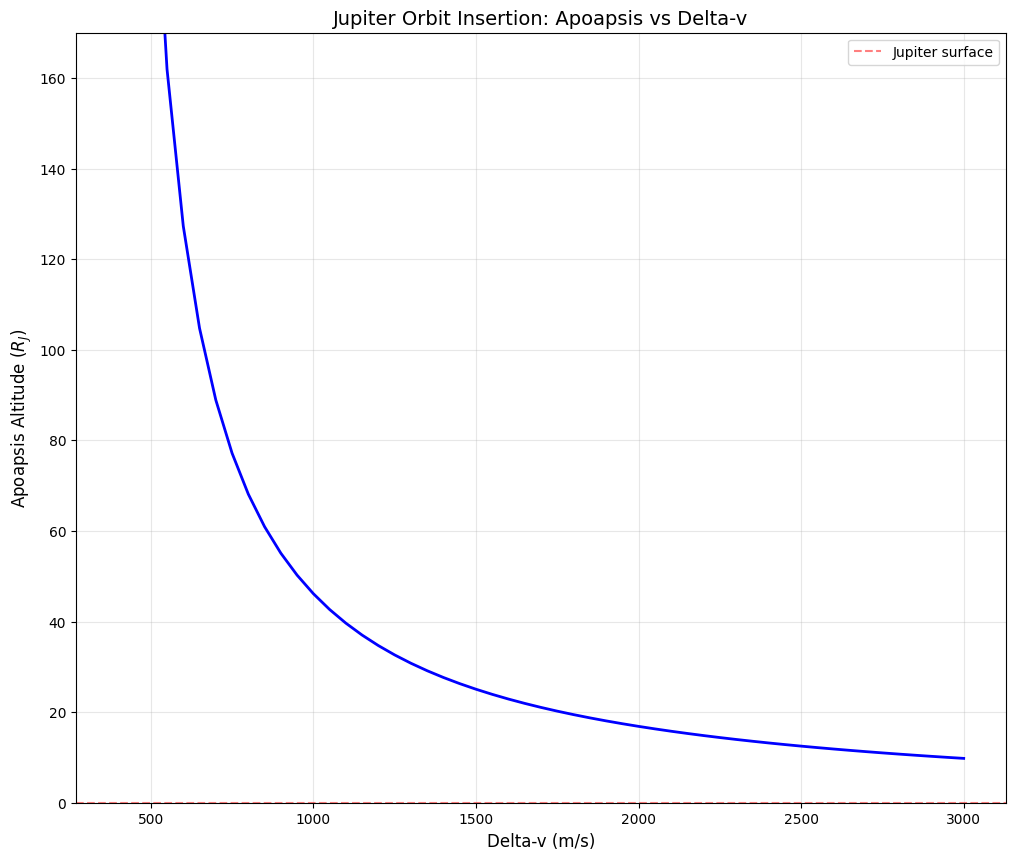

In [137]:
## Calculate apoapsis reduction vs delta-v for Jupiter orbit insertion

# Parameters
c3_arrival = c3_a  # From previous calculation
r_perijove = r_p + body_2.R  # Periapsis distance from Jupiter center
max_dv = 3 * u.km / u.s  # Maximum delta-v to test
dv_step = 0.05 * u.km / u.s  # Delta-v step size

# Arrays to store results
dv_values = []
apoapsis_values = []
period_values = []

# Calculate baseline (no burn) apoapsis
a_hyp = -(body_2.k / c3_arrival).to(u.km)
ecc_hyp = 1 - r_perijove / a_hyp
# baseline_orbit = Orbit.from_classical(
#     body_2,
#     a_hyp,
#     ecc_hyp,
#     0 * u.deg,
#     0 * u.deg,
#     0 * u.deg,
#     0 * u.deg,
#     time.Time(date_arrival, scale="utc"),
# )
baseline_orbit=arrival_orbit
v_inf = np.linalg.norm(baseline_orbit.v)

print(f"Baseline hyperbolic approach:")
print(f"  C3: {c3_arrival}")
print(f"  V∞ at periapsis: {v_inf.to(u.km/u.s):.3f}")
print(f"  Periapsis: {r_perijove.to(u.km):.0f}")
print(f"\nScanning delta-v from 0 to {max_dv}...")

# Loop over delta-v values
current_dv = 0 * u.km / u.s
while current_dv <= max_dv:
    # Calculate velocity after retrograde burn
    v_after_burn = v_inf - current_dv
    
    # Calculate new orbit parameters
    # Specific energy: ε = v²/2 - μ/r
    epsilon = (v_after_burn**2 / 2) - (body_2.k / r_perijove)
    
    # Semi-major axis: a = -μ/(2ε)
    a_capture = -body_2.k / (2 * epsilon)
    
    # Eccentricity: e = 1 - r_p/a
    ecc_capture = 1 - r_perijove / a_capture
    
    # Check if orbit is elliptical (captured)
    if ecc_capture < 1.0:
        # Calculate apoapsis: r_a = a(1 + e)
        r_apoapsis = a_capture * (1 + ecc_capture)
        
        # Create the orbit to get period
        capture_orbit = Orbit.from_classical(
            body_2,
            a_capture,
            ecc_capture,
            0 * u.deg,
            0 * u.deg,
            0 * u.deg,
            0 * u.deg,
            time.Time(date_arrival, scale="utc"),
        )
        
        dv_values.append(current_dv.to(u.m/u.s).value)
        apoapsis_values.append((r_apoapsis - body_2.R).to(u.km).value)
        period_values.append(capture_orbit.period.to(u.day).value)
    else:
        # Still hyperbolic - no capture
        dv_values.append(current_dv.to(u.m/u.s).value)
        apoapsis_values.append(np.inf)
        period_values.append(np.inf)
    
    current_dv += dv_step

# Convert to arrays for plotting
dv_values = np.array(dv_values)
apoapsis_values = np.array(apoapsis_values)
period_values = np.array(period_values)

# Convert Jupiter radius to km for scaling
R_J = Jupiter.R.to(u.km).value

# Plot results
fig, (ax1) = plt.subplots(1, 1, figsize=(12, 10))

# Plot 1: Apoapsis vs Delta-v (in R_J)
# Filter out infinite values for plotting
finite_mask = np.isfinite(apoapsis_values)
apoapsis_RJ = apoapsis_values[finite_mask] / R_J  # Convert to R_J
ax1.plot(dv_values[finite_mask], apoapsis_RJ, 'b-', linewidth=2)
ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Jupiter surface')
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('Delta-v (m/s)', fontsize=12)
ax1.set_ylabel('Apoapsis Altitude ($R_J$)', fontsize=12)
ax1.set_title('Jupiter Orbit Insertion: Apoapsis vs Delta-v', fontsize=14)

ax1.set_ylim(top=170,bottom=0)
ax1.legend(loc='upper right')

print(f"\nJupiter radius: {R_J:.0f} km")
print(f"\nKey results:")
if len(dv_values[finite_mask]) > 0:
    print(f"Minimum ΔV for capture: {dv_values[finite_mask][0]:.1f} m/s")
    print(f"  → Apoapsis: {apoapsis_RJ[0]:.1f} R_J ({apoapsis_values[finite_mask][0]:.0f} km)")
    print(f"  → Period: {period_values[finite_mask][0]:.1f} days")
  
target_a_p=165
idx=np.argmin(np.abs(target_a_p-apoapsis_RJ))
dv_req=dv_values[finite_mask][idx]
print(f"Requires {dv_req:.3f}m/s to hit {target_a_p} R_J apijove")
